# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _Muhammad SUFIAN_

**Roll Number:** _023-24-0007_

**GitHub Repository:** _(link, added before submission)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [26]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("data.csv")   # update path/filename if different


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_The company wants to predict **customer churn** — whether a customer will stop using the telecom service — so it can identify at-risk customers early and intervene (e.g. with discounts or better service) before they leave. The target variable is almost certainly the `Churn` _

**Answer 2:**
_Likely useful predictors: `OnlineSecurity`, `tenure`, `MonthlyCharges` , `TechSupport` , `TotalCharges` 
Likely useless predictors: `customerID` , `gender`_ 

**Answer 3:**
_1. Do customers on flexible contracts churn far more often than those locked into annual contracts?
2. Does the length of time someone has been a customer (tenure) protect against churn, i.e. do newer customers leave faster than long-time customers?_

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [50]:
# Task 4 — dataset shape, column names, data types

print("Number of customers (rows):", df.shape[0])
print("Number of features (columns):", df.shape[1])
print()
print("Columns:", list(df.columns))
print()
print(df.dtypes)
print()

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

Number of customers (rows): 7043
Number of features (columns): 21

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: obje

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10896\216461450.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


In [51]:
# Task 5 — identify identifier columns / wrong data types
# customerID is a pure identifier (unique per row, no predictive value)
print("customerID unique values == rows?", df['customerID'].nunique() == len(df))

print(df['SeniorCitizen'].unique())

print(df['TotalCharges'].dtype)
print(df['TotalCharges'].head())


customerID unique values == rows? True
[0 1]
float64
0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64


In [52]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
# Task 6 — unique values in 3 categorical columns
print(df["Partner"].unique())
print(df["Dependents"].unique())
print(df["PhoneService"].unique())

<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


---

**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [54]:
# Task 7 — missing values: count and percentage per column
print(f"missing values count per column {df.isnull().sum()}")
print(f"missing values percentage per column {((df.isnull().sum()/len(df))*100)}")

missing values count per column customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
missing values percentage per column customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000


In [55]:
# Task 8 — duplicate rows vs duplicate IDs
df.duplicated().sum()

np.int64(0)

In [57]:
# Task 9 — investigate a suspicious / invalid value
for col in df.select_dtypes(include='str').columns:
    unique_values = df[col].unique().tolist()
    
    print(f"\n{col}: {len(unique_values)} unique values")
    
    if len(unique_values) <= 10:
        print("Values:", unique_values)

for col in df.select_dtypes(include='number').columns:
    print(f"{col}: Min = {df[col].min()}, Max = {df[col].max()}")


customerID: 7043 unique values

gender: 2 unique values
Values: ['Female', 'Male']

Partner: 2 unique values
Values: ['Yes', 'No']

Dependents: 2 unique values
Values: ['No', 'Yes']

PhoneService: 2 unique values
Values: ['No', 'Yes']

MultipleLines: 3 unique values
Values: ['No phone service', 'No', 'Yes']

InternetService: 3 unique values
Values: ['DSL', 'Fiber optic', 'No']

OnlineSecurity: 3 unique values
Values: ['No', 'Yes', 'No internet service']

OnlineBackup: 3 unique values
Values: ['Yes', 'No', 'No internet service']

DeviceProtection: 3 unique values
Values: ['No', 'Yes', 'No internet service']

TechSupport: 3 unique values
Values: ['No', 'Yes', 'No internet service']

StreamingTV: 3 unique values
Values: ['No', 'Yes', 'No internet service']

StreamingMovies: 3 unique values
Values: ['No', 'Yes', 'No internet service']

Contract: 3 unique values
Values: ['Month-to-month', 'One year', 'Two year']

PaperlessBilling: 2 unique values
Values: ['Yes', 'No']

PaymentMethod: 4 uni

**Answer 7 (which missing-value problems need action, and why):**
_df.isnull().sum() shows no missing values, but TotalCharges has 11 empty strings because it is stored as text; these should be converted to numeric (making them NaN) and then dropped or filled with 0 since all have tenure = 0_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_Duplicate rows and duplicate customer IDs are different issues; duplicate rows mean identical records, while duplicate IDs mean the same customer appears more than once, and in this dataset both counts are 0_

**Answer 9 (suspicious value found and how):**
_he suspicious values were found by checking that TotalCharges was an object column and filtering for empty/whitespace values, which revealed 11 blank entries, all with tenure = 0_

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| _e.g. TotalCharges stored as text_ | _..._ | _..._ | _..._ |
| _..._ | _..._ | _..._ | _..._ |
| _..._ | _..._ | _..._ | _..._ |

In [58]:
# Task 11 — apply your cleaning decisions here
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

In [59]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("dtypes after cleaning:")
print(df.dtypes)
print()
print("Missing values after cleaning:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())
print()
print("New shape:", df.shape)

dtypes after cleaning:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract     

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

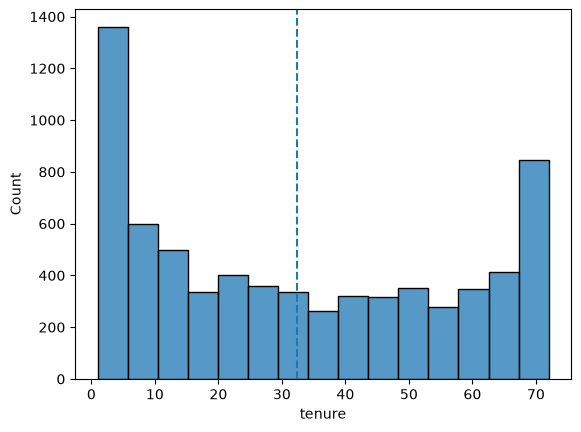

In [60]:
# Task 12 — numerical feature 1: distribution plot
df.head()
sns.histplot(df["tenure"]); plt.axvline(df["tenure"].mean(), linestyle="--")



**Observation:** _(what did you learn from this chart?)_

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

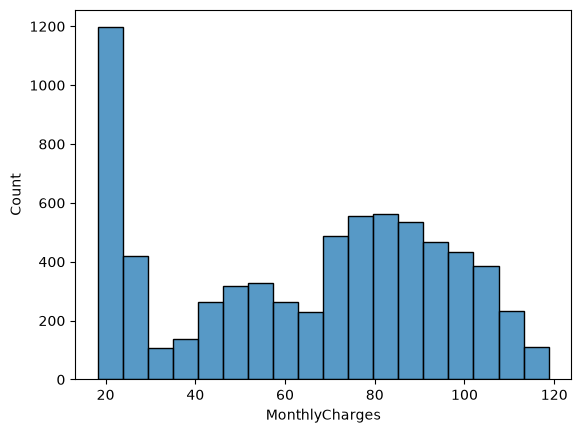

In [61]:
# Task 12 — numerical feature 2: distribution plot
sns.histplot(df['MonthlyCharges'])

**Observation:** _(what did you learn from this chart?)_

<Axes: ylabel='gender'>

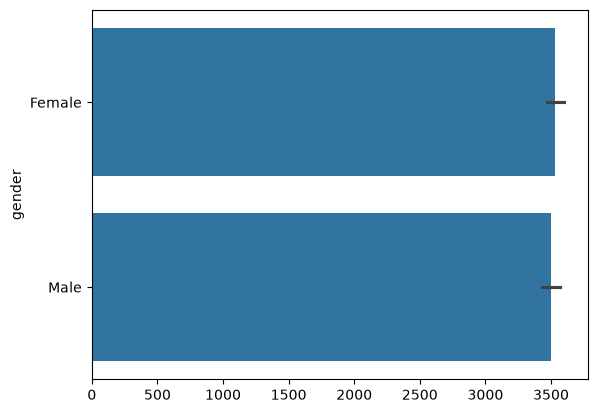

In [62]:
# Task 12 — categorical feature 1: distribution plot
sns.barplot(df["gender"])

**Observation:** _(what did you learn from this chart?)_

<Axes: ylabel='Partner'>

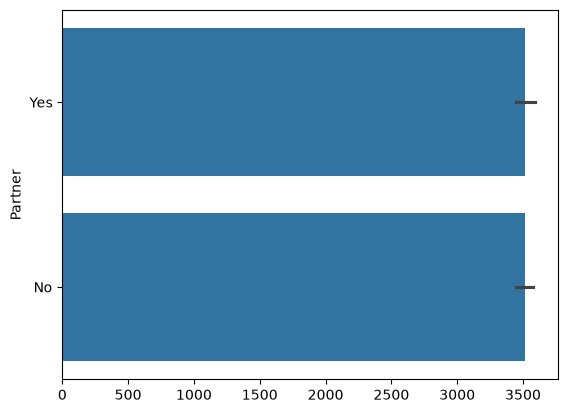

In [63]:
# Task 12 — categorical feature 2: distribution plot
sns.barplot(df["Partner"])

**Observation:** _(what did you learn from this chart?)_

**Answer 13 (outliers / skew and possible explanation):**
_tenure is bimodal and MonthlyCharges is multimodal due to customer segments and pricing tiers, with no major outliers or obvious data errors._

<Axes: ylabel='tenure'>

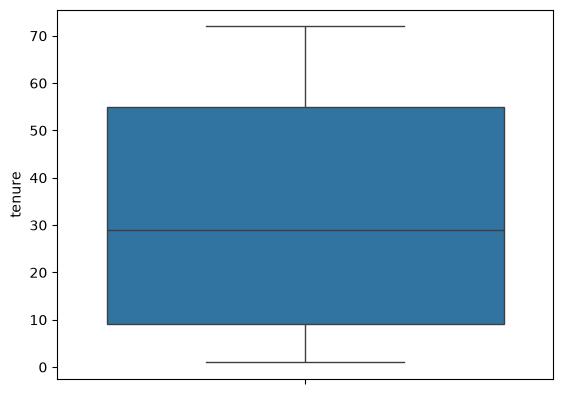

In [64]:
sns.boxplot(df["tenure"])

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

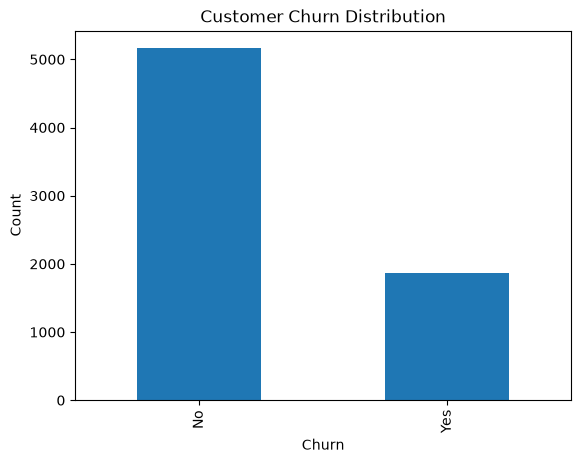

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentages:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [65]:
# Task 14 — churn counts and percentages
df['Churn'].value_counts().plot(kind='bar')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Customer Churn Distribution')
plt.show()

# Also print counts and percentages
print(df['Churn'].value_counts())
print("\nPercentages:")
print(df['Churn'].value_counts(normalize=True) * 100)

**Answer 14 (balanced or imbalanced?):**
_The target is **imbalanced**: about 5,163 customers (73.5%) did not churn ("No") while about 1,869 (26.5%) did churn ("Yes") — roughly a 3:1 ratio_

**Answer 15 (why imbalance might matter later):**
_ Imbalanced data can make accuracy misleading because a model may predict the majority class (No Churn) most of the time while failing to detect customers who churn, so metrics like precision, recall, and F1 are important.
_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

<Axes: xlabel='Contract', ylabel='count'>

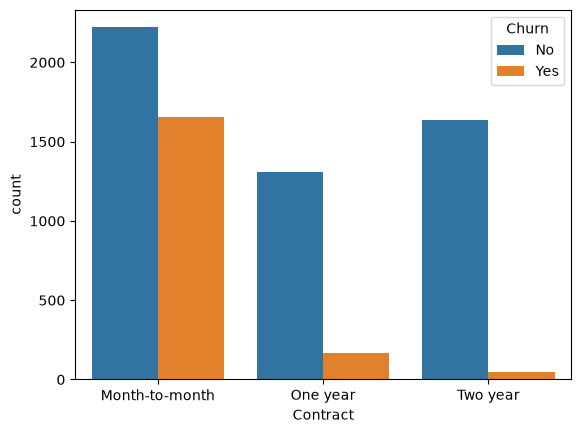

In [66]:
# Task 16 — categorical feature 1 vs Churn
sns.countplot(x='Contract', hue='Churn', data=df)

**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

<Axes: xlabel='Churn', ylabel='count'>

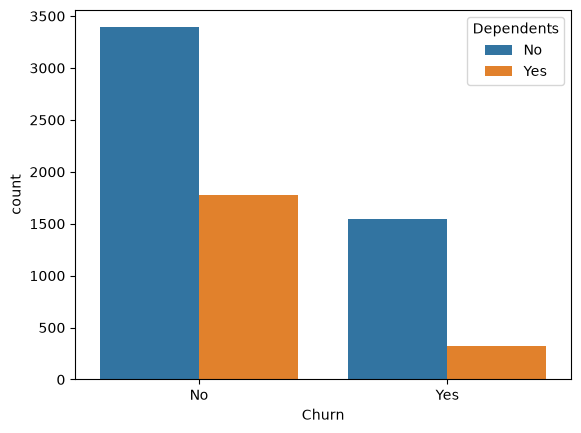

In [67]:
# Task 16 — categorical feature 2 vs Churn
sns.countplot(x='Churn', hue='Dependents', data=df)

**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

<Axes: xlabel='tenure', ylabel='Count'>

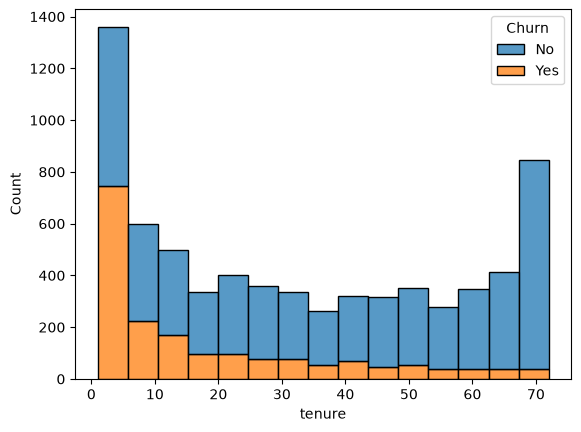

In [68]:
# Task 17 — numerical feature 1 vs Churn
sns.histplot(x='tenure', hue='Churn', data=df, multiple='stack')

**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

        count       mean        std    min    25%    50%     75%     max
Churn                                                                   
No     5163.0  61.307408  31.094557  18.25  25.10  64.45  88.475  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.65  94.200  118.35


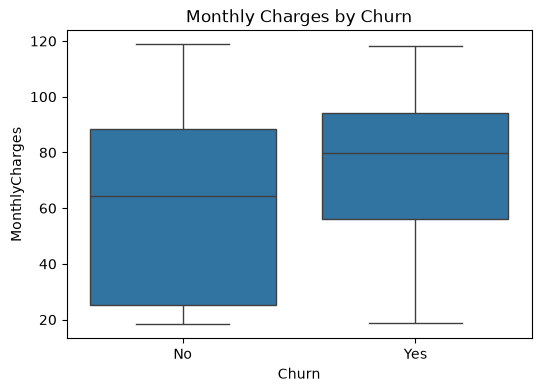

In [69]:
# Task 17 — numerical feature 2 vs Churn
print(df.groupby('Churn')['MonthlyCharges'].describe())

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn')
plt.show()

**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

<Axes: >

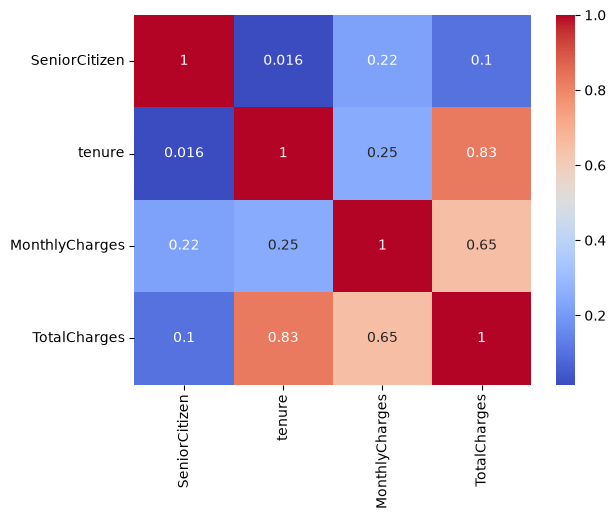

In [70]:
# Task 18 — correlation matrix and heatmap
# Task 18 — correlation matrix and heatmap
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

**Answer 18 (most correlated pairs):**
_TotalCharges has the strongest correlation with tenure (r ≈ 0.83) and MonthlyCharges (r ≈ 0.65) because it accumulates monthly charges over tenure_

**Answer 19 (correlation vs. causation; potential problems):**
_Correlation does not imply causation, and using all three variables may cause multicollinearity and redundant information_

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_customerID should be excluded as it has no predictive meaning, while TotalCharges should be used cautiously because it can indirectly reflect the customer’s churn timeline_

**Answer 21 (what would go wrong):**
_Data leakage can make a model appear highly accurate during testing but fail in real-world use because the leaked information is unavailable at prediction time._

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique per row, no predictive value |
| gender | Categorical | Feature | Keep (encode) | Nearly balanced; potential weak predictor, encode for modeling |
| SeniorCitizen | Categorical (0/1) | Feature | Keep | Already numeric/binary, usable as-is |
| Partner | Categorical | Feature | Keep (encode) | Household context may relate to churn |
| Dependents | Categorical | Feature | Keep (encode) | Household context may relate to churn |
| tenure | Numerical | Feature | Keep | Strong observed relationship with churn |
| PhoneService | Categorical | Feature | Keep (encode) | Describes subscribed services |
| MultipleLines | Categorical | Feature | Keep (encode) | Service usage detail |
| InternetService | Categorical | Feature | Keep (encode) | Strong observed relationship with churn |
| OnlineSecurity | Categorical | Feature | Keep (encode) | Add-on service, may reduce churn |
| OnlineBackup | Categorical | Feature | Keep (encode) | Add-on service, may reduce churn |
| DeviceProtection | Categorical | Feature | Keep (encode) | Add-on service, may reduce churn |
| TechSupport | Categorical | Feature | Keep (encode) | Add-on service, may reduce churn |
| StreamingTV | Categorical | Feature | Keep (encode) | Add-on service usage |
| StreamingMovies | Categorical | Feature | Keep (encode) | Add-on service usage |
| Contract | Categorical | Feature | Keep (encode) | Strongest observed predictor of churn |
| PaperlessBilling | Categorical | Feature | Keep (encode) | Billing behavior, possible mild signal |
| PaymentMethod | Categorical | Feature | Keep (encode) | Historically linked to churn (e.g. electronic check) |
| MonthlyCharges | Numerical | Feature | Keep | Clear relationship with churn |
| TotalCharges | Numerical | Feature (use cautiously) | Keep, but watch multicollinearity | Highly correlated with tenure × MonthlyCharges |
| Churn | Categorical | Target | Keep | This is the variable to predict |


---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [71]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# ... apply your cleaning steps here ...

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


In [72]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
clean_df.info()
print()
print("Missing values:\n", clean_df.isnull().sum())
print()
print("Duplicate rows:", clean_df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

**Finding 1**
- Observation: Contract type is the single strongest driver of churn.
- Evidence: Month-to-month churn = 42.7%, one-year = 11.3%, two-year = 2.8%.
- Interpretation: Locking customers into longer commitments (via pricing incentives or perceived value) could meaningfully reduce churn.

**Finding 2**
- Observation: Newer customers churn far more than long-tenured ones.
- Evidence: Median tenure of churned customers is 10 months vs. 38 months for retained customers.
- Interpretation: The first year of service is the highest-risk period; onboarding experience and early engagement likely matter most for retention.

**Finding 3**
- Observation: Fiber optic internet customers churn at a much higher rate than DSL or no-internet customers.
- Evidence: Fiber optic churn = 41.9% vs. DSL = 19.0% vs. no internet = 7.4%.
- Interpretation: Fiber optic's higher price point and/or service quality issues may be a specific pain point worth investigating operationally.

**Finding 4**
- Observation: Churned customers pay higher monthly charges on average.
- Evidence: Median MonthlyCharges is $79.65 for churned vs. $64.45 for retained customers.
- Interpretation: Price sensitivity appears to be a real driver of churn, especially combined with short tenure and fiber service.

**Finding 5**
- Observation: The target class is imbalanced (73.5% No / 26.5% Yes), and `TotalCharges` is highly correlated with `tenure` and `MonthlyCharges`.
- Evidence: Churn value_counts and the numerical correlation heatmap (r ≈ 0.83 and 0.65).
- Interpretation: Lab 3 modeling must account for class imbalance (e.g. via appropriate metrics/class weighting) and consider redundancy between `TotalCharges` and the two features it's derived from.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   The `TotalCharges` column being stored as text with 11 hidden blank-string entries (not caught by `isnull()`) tied to customers with zero tenure — an easy issue to miss if you only rely on `isnull().sum()`.
2. What was the most interesting pattern you discovered?
   How strongly contract type predicts churn — a 15x difference in churn rate between two-year and month-to-month customers is a much bigger effect than most demographic factors like gender.
3. Which feature seems most useful for predicting churn?
   `Contract`, closely followed by `tenure` — both show large, consistent differences in churn rate across their categories/ranges.
4. Which feature should probably not be used, and why?
   `customerID` — it's a random unique identifier with no relationship to the outcome and would only add noise or risk overfitting if used as a feature. `gender` is also weak, being nearly balanced with no strong observed effect on churn.


---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [49]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook